# Decomposition of circulatory amino acids

How much flux does protein degratation explain?

In [1]:
import pandas as pd 

fcirc = pd.read_csv('data/Fcirc_07.01.2026.10.50.58.tsv', sep='\t', index_col=0)

# make sure columns that should be numeric are numeric
numeric_cols = ['Body Weight (g)', 'Age (weeks)', 'Infusion Rate (ul/min/g)',
        'Tracer Concentration (mM)', 'Time Collected (m)', 'Average Ra (nmol/min/g)',
        'Average Rd (nmol/min/g)', 'Average Ra (nmol/min)',
        'Average Rd (nmol/min)', 'Intact Ra (nmol/min/g)',
        'Intact Rd (nmol/min/g)', 'Intact Ra (nmol/min)',
        'Intact Rd (nmol/min)']

for col in numeric_cols:
    fcirc[col] = pd.to_numeric(fcirc[col], errors='coerce')


# Filter data collected time > 120 minutes
fcirc = fcirc[fcirc['Time Collected (m)'] > 120]
fcirc_c = fcirc[fcirc['Labeled Element'] == 'C']
fcirc_n = fcirc[fcirc['Labeled Element'] == 'N']

# Drop rows with missing values in 'Intact Rd (nmol/min/g)'
fcirc_c = fcirc_c.dropna(subset=['Intact Rd (nmol/min/g)'])
fcirc_n = fcirc_n.dropna(subset=['Intact Rd (nmol/min/g)'])



In [2]:
fcirc.columns

Index(['Studies', 'Genotype', 'Body Weight (g)', 'Age (weeks)', 'Sex', 'Diet',
       'Feeding Status', 'Treatment', 'Tracer Compound', 'Labeled Element',
       'Infusion Rate (ul/min/g)', 'Tracer Concentration (mM)',
       'Time Collected (m)', 'Average Ra (nmol/min/g)',
       'Average Rd (nmol/min/g)', 'Average Ra (nmol/min)',
       'Average Rd (nmol/min)', 'Intact Ra (nmol/min/g)',
       'Intact Rd (nmol/min/g)', 'Intact Ra (nmol/min)',
       'Intact Rd (nmol/min)'],
      dtype='object')

In [3]:
# Availebl tracer compounds
fcirc['Tracer Compound'].unique()

array(['C16:0', 'lysine', 'glucose', 'lactate', 'glutamine', 'alanine',
       'arginine', '3-hydroxybutyrate', 'C18:1', 'leucine', 'glycine',
       'acetate', 'glycerol', 'citrate', 'C18:2', 'valine', 'isoleucine',
       'methionine', 'phenylalanine', 'tryptophan', 'histidine',
       'threonine', 'proline', 'ornithine', 'serine', 'a-ketoglutarate',
       'aspartate', 'carnosine', 'beta-alanine', 'water', 'cysteine',
       'L-cystine'], dtype=object)

In [4]:
# Fliter out only amino acid tracers
fcirc_aa = fcirc_c[fcirc_c['Tracer Compound'].isin([
    'lysine',
    'glutamine',
    'alanine',
    'arginine',
    'leucine',
    'glycine',
    'proline',
    'serine',
    'aspartate',
    'valine',
    'isoleucine',
    'methionine',
    'phenylalanine',
    'tryptophan',
    'histidine',
    'threonine',
    'L-cystine'
])]

In [5]:
# Remove outliers in lysine, arginine and aspartate
fcirc_aa = fcirc_aa[~((fcirc_aa['Tracer Compound'] == 'lysine') & (fcirc_aa['Intact Rd (nmol/min/g)'] > 100))]
fcirc_aa = fcirc_aa[~((fcirc_aa['Tracer Compound'] == 'arginine') & (fcirc_aa['Intact Rd (nmol/min/g)'] > 100))]
fcirc_aa = fcirc_aa[~((fcirc_aa['Tracer Compound'] == 'aspartate') & (fcirc_aa['Intact Rd (nmol/min/g)'] > 100))]

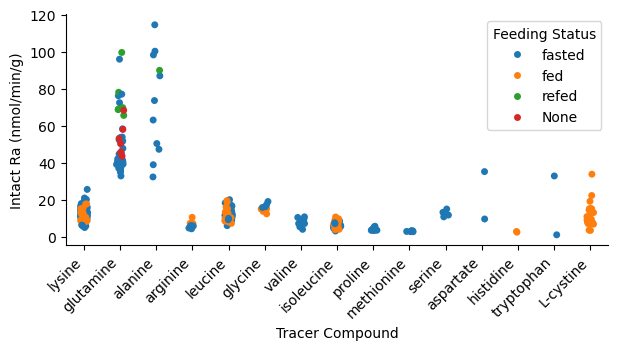

In [6]:
# Make a seaborn barplot of Rd (nmol/min/g) for each amino acid tracer
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
sns.stripplot(data=fcirc_aa, x='Tracer Compound', y='Intact Ra (nmol/min/g)', hue='Feeding Status')
plt.xticks(rotation=45, ha='right')
sns.despine()


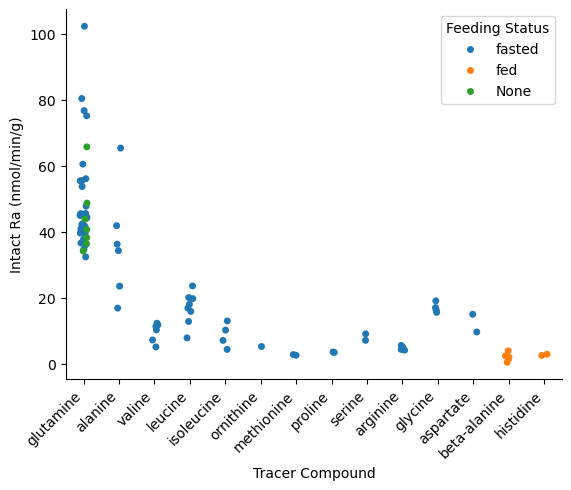

In [7]:
# Plot all nitrogen f circ data
fcirc_n = fcirc_n[~((fcirc_n['Tracer Compound'] == 'aspartate') & (fcirc_n['Intact Rd (nmol/min/g)'] > 100))]
# Remove outliers in lysine, arginine and aspartate
fcirc_c = fcirc_c[~((fcirc_c['Tracer Compound'] == 'lysine') & (fcirc_c['Intact Rd (nmol/min/g)'] > 100))]
fcirc_c = fcirc_c[~((fcirc_c['Tracer Compound'] == 'arginine') & (fcirc_c['Intact Rd (nmol/min/g)'] > 100))]
fcirc_c = fcirc_c[~((fcirc_c['Tracer Compound'] == 'aspartate') & (fcirc_c['Intact Rd (nmol/min/g)'] > 100))]

sns.stripplot(data=fcirc_n, x='Tracer Compound', y='Intact Ra (nmol/min/g)', hue='Feeding Status')
plt.xticks(rotation=45, ha='right')
sns.despine()


/var/folders/n5/kq0k2frx06l30kyysqmgk1lw0000gn/T/ipykernel_63095/810268115.py:29: UserWarning: The markers list has more values (15) than needed (13), which may not be intended.
  sns.scatterplot(data=comparison_df, x='Mean Ra C (nmol/min/g)', y='Mean Ra N (nmol/min/g)',  style='Tracer', hue='Tracer',


Text(0.5, 0, 'Carbon tracer $F_{circ}$ (nmol/min/g)')

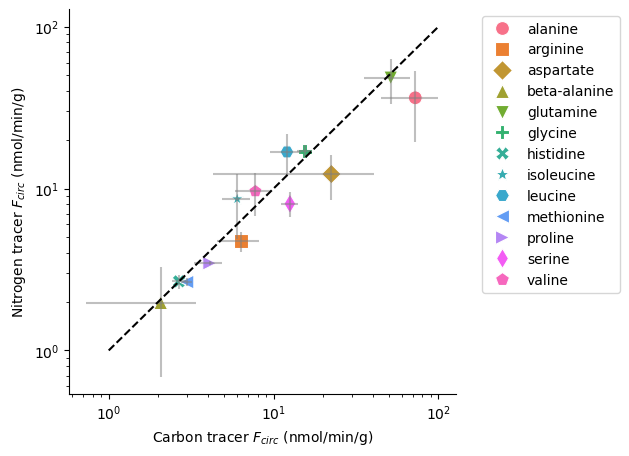

In [8]:
# Nitrogen vs Carbon Ra comparison
sel = 'Intact'

mean_ra_c = fcirc_c.groupby('Tracer Compound')[f'{sel} Ra (nmol/min/g)'].mean()
mean_ra_n = fcirc_n.groupby('Tracer Compound')[f'{sel} Ra (nmol/min/g)'].mean()

# Add std deviation columns
std_ra_c = fcirc_c.groupby('Tracer Compound')[f'{sel} Ra (nmol/min/g)'].std()
std_ra_n = fcirc_n.groupby('Tracer Compound')[f'{sel} Ra (nmol/min/g)'].std()


comparison_df = pd.DataFrame({
    'Mean Ra C (nmol/min/g)': mean_ra_c,
    'Mean Ra N (nmol/min/g)': mean_ra_n,
    'Std Ra C (nmol/min/g)': std_ra_c,
    'Std Ra N (nmol/min/g)': std_ra_n
}).dropna()

# Add acolumns for tracer compound class -> index
comparison_df['Tracer']= comparison_df.index

f = plt.figure(figsize=(5, 5))

# Add error bars
plt.errorbar(comparison_df['Mean Ra C (nmol/min/g)'], comparison_df['Mean Ra N (nmol/min/g)'],
             xerr=comparison_df['Std Ra C (nmol/min/g)'], yerr=comparison_df['Std Ra N (nmol/min/g)'],
             fmt='none', ecolor='gray', alpha=0.5)

sns.scatterplot(data=comparison_df, x='Mean Ra C (nmol/min/g)', y='Mean Ra N (nmol/min/g)',  style='Tracer', hue='Tracer',
                markers=['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'H', '<', '>', 'd', 'p', 'h', '8'],
                s=100)

plt.plot([1, 100], [1, 100], 'k--')
plt.xscale('log')
plt.yscale('log')   
# Add legend outside plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

# X and Y labels
plt.ylabel('Nitrogen tracer $F_{circ}$ (nmol/min/g)')
plt.xlabel('Carbon tracer $F_{circ}$ (nmol/min/g)')

In [9]:
# Amino acid frequency analysis from UniProt sequences
# Analyze the amino acid composition of mouse proteins from the downloaded FASTA file

In [10]:
from pathlib import Path
from utils import analyze_amino_acid_frequency, get_amino_acid_names

# Analyze the downloaded mouse sequences
fasta_path = Path('data/mouse_sequences.fasta')

aa_counts, n_proteins, total_aa = analyze_amino_acid_frequency(fasta_path)

print(f"Analysis Summary:")
print(f"  Total proteins analyzed: {n_proteins:,}")
print(f"  Total amino acids counted: {total_aa:,}")
print(f"  Average protein length: {total_aa/n_proteins:.1f} aa")
print(f"\nAmino acid counts:")

# Convert to DataFrame for better display
aa_freq_df = pd.DataFrame({
    'Amino Acid': list(aa_counts.keys()),
    'Count': list(aa_counts.values())
})

# Calculate frequency (percentage)
aa_freq_df['Frequency (%)'] = (aa_freq_df['Count'] / total_aa) * 100

# Sort by frequency
aa_freq_df = aa_freq_df.sort_values('Frequency (%)', ascending=False)

# Add amino acid full names
aa_names = get_amino_acid_names()
aa_freq_df['Full Name'] = aa_freq_df['Amino Acid'].map(aa_names)

# Reorder columns
aa_freq_df = aa_freq_df[['Amino Acid', 'Full Name', 'Count', 'Frequency (%)']]

aa_freq_df

Analysis Summary:
  Total proteins analyzed: 17,240
  Total amino acids counted: 9,800,678
  Average protein length: 568.5 aa

Amino acid counts:


,Amino Acid,Full Name,Count,Frequency (%)
7,L,leucine,985101,10.051356
9,S,serine,825016,8.417948
11,E,glutamate,690793,7.048421
12,A,alanine,685392,6.993312
2,G,glycine,637365,6.503275
3,P,proline,607407,6.197602
16,V,valine,599722,6.119189
8,K,lysine,554099,5.653680
5,R,arginine,551120,5.623284
4,T,threonine,525584,5.362731


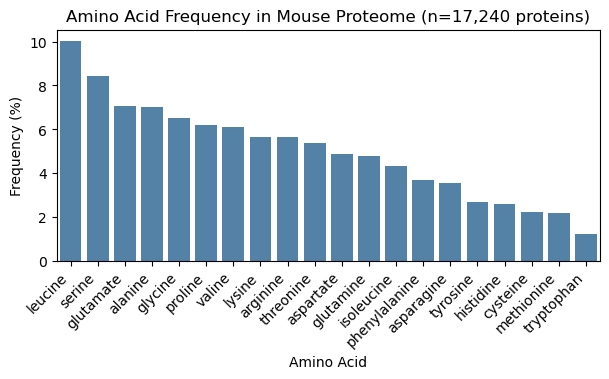

In [11]:
# Visualize amino acid frequency
plt.figure(figsize=(7, 3))
sns.barplot(data=aa_freq_df, x='Full Name', y='Frequency (%)', color='steelblue')
plt.xlabel('Amino Acid')
plt.ylabel('Frequency (%)')
plt.title(f'Amino Acid Frequency in Mouse Proteome (n={n_proteins:,} proteins)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [12]:
# Compute amino acid abundance from hydrolysis data
aa_comp = pd.read_csv('./data/mouse_aa_abundance.tsv', index_col=0)

# Make the index lowercase
aa_comp.index = aa_comp.index.str.lower()

# Remove any duplicate amino acids by keeping the first occurrence
aa_comp = aa_comp[~aa_comp.index.duplicated(keep='first')]

percent_dry_mass = aa_comp['Mean'].sum()

# Mass abundance (% of total amino acid mass)
aa_comp['Mass %'] = aa_comp['Mean'] / percent_dry_mass * 100

# Molecular weights of amino acids (g/mol) - all lowercase keys
molecular_weights = {
    'alanine': 89.09,
    'arginine': 174.20,
    'asparagine': 132.12,
    'aspartate': 133.10,
    'cysteine': 121.16,
    'glutamate': 147.13,
    'glutamine': 146.15,
    'glycine': 75.07,
    'histidine': 155.15,
    'isoleucine': 131.17,
    'leucine': 131.17,
    'lysine': 146.19,
    'methionine': 149.21,
    'phenylalanine': 165.19,
    'proline': 115.13,
    'serine': 105.09,
    'threonine': 119.12,
    'tryptophan': 204.23,
    'tyrosine': 181.19,
    'valine': 117.15
}

# Add molecular weight column
aa_comp['MW (g/mol)'] = aa_comp.index.map(molecular_weights)

# Get molar ratios from UniProt proteome analysis
glu_freq = aa_freq_df[aa_freq_df['Amino Acid'] == 'E']['Frequency (%)'].values[0]
gln_freq = aa_freq_df[aa_freq_df['Amino Acid'] == 'Q']['Frequency (%)'].values[0]
glu_fraction = glu_freq / (glu_freq + gln_freq)
gln_fraction = gln_freq / (glu_freq + gln_freq)

asp_freq = aa_freq_df[aa_freq_df['Amino Acid'] == 'D']['Frequency (%)'].values[0]
asn_freq = aa_freq_df[aa_freq_df['Amino Acid'] == 'N']['Frequency (%)'].values[0]
asp_fraction = asp_freq / (asp_freq + asn_freq)
asn_fraction = asn_freq / (asp_freq + asn_freq)

print(f"Glutamate/Glutamine ratio from proteome: {glu_fraction:.1%}/{gln_fraction:.1%}")
print(f"Aspartate/Asparagine ratio from proteome: {asp_fraction:.1%}/{asn_fraction:.1%}")

# Split glutamate based on proteome molar ratio
if 'glutamate' in aa_comp.index:
    glu_mass = aa_comp.loc['glutamate', 'Mean']
    glu_mass_pct = aa_comp.loc['glutamate', 'Mass %']
    
    # Update glutamate based on proteome ratio
    aa_comp.loc['glutamate', 'Mean'] = glu_mass * glu_fraction
    aa_comp.loc['glutamate', 'Mass %'] = glu_mass_pct * glu_fraction
    
    # Add or update glutamine based on proteome ratio
    if 'glutamine' not in aa_comp.index:
        aa_comp.loc['glutamine', 'Mean'] = glu_mass * gln_fraction
        aa_comp.loc['glutamine', 'Mass %'] = glu_mass_pct * gln_fraction
        aa_comp.loc['glutamine', 'MW (g/mol)'] = molecular_weights['glutamine']
    else:
        aa_comp.loc['glutamine', 'Mean'] += glu_mass * gln_fraction
        aa_comp.loc['glutamine', 'Mass %'] += glu_mass_pct * gln_fraction

# Split aspartate based on proteome molar ratio
if 'aspartate' in aa_comp.index:
    asp_mass = aa_comp.loc['aspartate', 'Mean']
    asp_mass_pct = aa_comp.loc['aspartate', 'Mass %']
    
    # Update aspartate based on proteome ratio
    aa_comp.loc['aspartate', 'Mean'] = asp_mass * asp_fraction
    aa_comp.loc['aspartate', 'Mass %'] = asp_mass_pct * asp_fraction
    
    # Add or update asparagine based on proteome ratio
    if 'asparagine' not in aa_comp.index:
        aa_comp.loc['asparagine', 'Mean'] = asp_mass * asn_fraction
        aa_comp.loc['asparagine', 'Mass %'] = asp_mass_pct * asn_fraction
        aa_comp.loc['asparagine', 'MW (g/mol)'] = molecular_weights['asparagine']
    else:
        aa_comp.loc['asparagine', 'Mean'] += asp_mass * asn_fraction
        aa_comp.loc['asparagine', 'Mass %'] += asp_mass_pct * asn_fraction

# Add hydroxyproline to proline
if 'hydroxyproline' in aa_comp.index:
    hypro_mass = aa_comp.loc['hydroxyproline', 'Mean']
    hypro_mass_pct = aa_comp.loc['hydroxyproline', 'Mass %']
    
    if 'proline' in aa_comp.index:
        aa_comp.loc['proline', 'Mean'] += hypro_mass
        aa_comp.loc['proline', 'Mass %'] += hypro_mass_pct
    else:
        aa_comp.loc['proline', 'Mean'] = hypro_mass
        aa_comp.loc['proline', 'Mass %'] = hypro_mass_pct
        aa_comp.loc['proline', 'MW (g/mol)'] = molecular_weights['proline']
    
    # Remove hydroxyproline row
    aa_comp = aa_comp.drop('hydroxyproline')

# Add hydroxylysine to lysine
if 'hydroxylysine' in aa_comp.index:
    hylys_mass = aa_comp.loc['hydroxylysine', 'Mean']
    hylys_mass_pct = aa_comp.loc['hydroxylysine', 'Mass %']
    
    if 'lysine' in aa_comp.index:
        aa_comp.loc['lysine', 'Mean'] += hylys_mass
        aa_comp.loc['lysine', 'Mass %'] += hylys_mass_pct
    else:
        aa_comp.loc['lysine', 'Mean'] = hylys_mass
        aa_comp.loc['lysine', 'Mass %'] = hylys_mass_pct
        aa_comp.loc['lysine', 'MW (g/mol)'] = molecular_weights['lysine']
    
    # Remove hydroxylysine row
    aa_comp = aa_comp.drop('hydroxylysine')

# Convert mass to moles (mass in g / MW in g/mol gives moles)
# Assuming the mass values are in g per 100g dry mass
aa_comp['Moles (mmol per 100g)'] = (aa_comp['Mean'] / aa_comp['MW (g/mol)']) * 1000  # Convert to mmol

# Calculate molar percentage
total_moles = aa_comp['Moles (mmol per 100g)'].sum()
aa_comp['Molar %'] = (aa_comp['Moles (mmol per 100g)'] / total_moles) * 100

# Display results
aa_comp[['Mass %', 'MW (g/mol)', 'Moles (mmol per 100g)', 'Molar %']].sort_values('Molar %', ascending=False)

Glutamate/Glutamine ratio from proteome: 59.7%/40.3%
Aspartate/Asparagine ratio from proteome: 57.8%/42.2%


,Mass %,MW (g/mol),Moles (mmol per 100g),Molar %
AA,,,,
glycine,7.702253,75.07,55.548155,12.978615
alanine,6.002955,89.09,36.479964,8.523405
leucine,8.090137,131.17,33.391782,7.801863
proline,7.092723,115.13,33.353600,7.792942
glutamate,7.858073,147.13,28.915657,6.756033
lysine,7.739195,146.19,28.661331,6.696611
valine,5.559660,117.15,25.693555,6.003201
serine,4.137421,105.09,21.315063,4.980183
arginine,6.649427,174.20,20.665901,4.828509


In [13]:
aa_comp

,1-2d,10_13d,21_25d,30-40d,150-180d,Mean,SD,Mass %,MW (g/mol),Moles (mmol per 100g),Molar %
AA,,,,,,,,,,,
arginine,3.24,2.98,4.06,3.80,3.93,3.600000,0.47,6.649427,174.20,20.665901,4.828509
histidine,1.44,1.15,1.50,1.38,1.50,1.390000,0.15,2.567418,155.15,8.959072,2.093253
isoleucine,2.10,1.81,2.37,2.20,2.24,2.140000,0.21,3.952715,131.17,16.314706,3.811869
leucine,4.26,3.69,4.81,4.44,4.68,4.380000,0.44,8.090137,131.17,33.391782,7.801863
lysine,3.88,3.36,4.48,4.07,4.34,4.190000,0.44,7.739195,146.19,28.661331,6.696611
methionine,1.09,0.97,1.31,1.21,1.30,1.180000,0.15,2.179535,149.21,7.908317,1.847748
phenylalanine,2.28,2.01,2.62,2.40,2.62,2.390000,0.26,4.414481,165.19,14.468188,3.380437
taurine,0.64,0.47,0.81,0.72,0.18,0.560000,0.25,1.034355,NaN,NaN,NaN
threonine,2.11,1.83,2.52,2.17,2.58,2.240000,0.31,4.137421,119.12,18.804567,4.393615


/var/folders/n5/kq0k2frx06l30kyysqmgk1lw0000gn/T/ipykernel_63095/2274589180.py:23: UserWarning: 
The markers list has fewer values (19) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


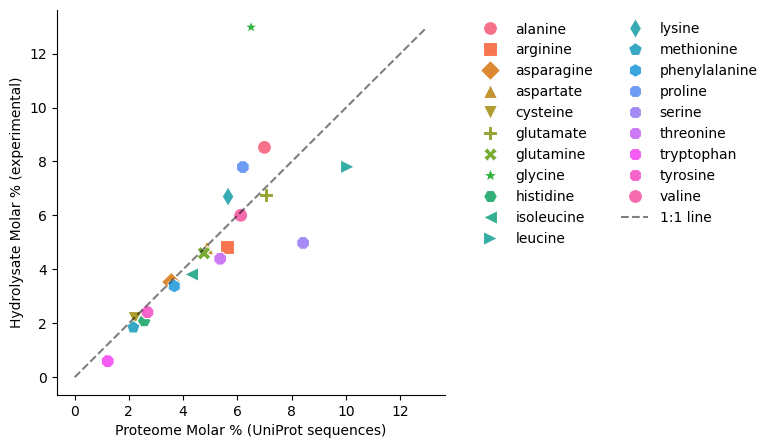


Correlation between proteome and hydrolysate: 0.757

Comparison of amino acid abundance:


,Proteome Molar %,Hydrolysate Molar %,Amino Acid
Full Name,,,
leucine,10.051356,7.801863,leucine
serine,8.417948,4.980183,serine
glutamate,7.048421,6.756033,glutamate
alanine,6.993312,8.523405,alanine
glycine,6.503275,12.978615,glycine
proline,6.197602,7.792942,proline
valine,6.119189,6.003201,valine
lysine,5.653680,6.696611,lysine
arginine,5.623284,4.828509,arginine


In [19]:
# Compare amino acid frequency from proteome vs hydrolysate abundance

# Prepare comparison dataframe
aa_comparison = pd.DataFrame()

# Add proteome frequency data - aggregate any duplicates
proteome_data = aa_freq_df.groupby('Full Name')['Frequency (%)'].first()
aa_comparison['Proteome Molar %'] = proteome_data

# Add hydrolysate molar abundance data 
aa_comparison.loc[aa_comparison.index,'Hydrolysate Molar %'] = aa_comp.loc[aa_comparison.index,'Molar %']

# Drop any rows with missing data
aa_comparison = aa_comparison.dropna()

# Create scatter plot comparison
# Add amino acid names as a column for seaborn
aa_comparison['Amino Acid'] = aa_comparison.index

fig, ax = plt.subplots(figsize=(5, 5))

# Use seaborn scatterplot with different markers and colors for each amino acid
sns.scatterplot(
    data=aa_comparison,
    x='Proteome Molar %',
    y='Hydrolysate Molar %',
    hue='Amino Acid',
    style='Amino Acid',
    markers=['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'H', '<', '>', 'd', 'p', 'h', '8', '8', '8', '8', '8'],
    s=100,
    ax=ax
)

# Add 1:1 line
max_val = max(aa_comparison['Proteome Molar %'].max(), aa_comparison['Hydrolysate Molar %'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='1:1 line')

ax.set_xlabel('Proteome Molar % (UniProt sequences)')
ax.set_ylabel('Hydrolysate Molar % (experimental)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, ncols=2)
sns.despine()
plt.show()

# Print correlation
correlation = aa_comparison['Proteome Molar %'].corr(aa_comparison['Hydrolysate Molar %'])
print(f"\nCorrelation between proteome and hydrolysate: {correlation:.3f}")

# Display table
print("\nComparison of amino acid abundance:")
aa_comparison.sort_values('Proteome Molar %', ascending=False)

In [17]:
# Also save the comparison data
comparison_file = './data/proteome_vs_hydrolysate_comparison.tsv'
aa_comparison.to_csv(comparison_file, sep='\t')
print(f"Saved proteome vs hydrolysate comparison to {comparison_file}")

Saved proteome vs hydrolysate comparison to ./data/proteome_vs_hydrolysate_comparison.tsv


In [15]:
# Protein degrattion fluxes in fasted mice are 10.5 nmol(valine)/g/min and 5.0 in fed mice

# Compute flux from protein degration baed on the amino acid frequency analysis
valine_freq = aa_freq_df[aa_freq_df['Amino Acid'] == 'V']['Frequency (%)'].values[0] / 100  # Convert to fraction

valine_flux_fasted = 10.2 # nmol/g/min
valine_flux_fed = 6.2 # nmol/g/min

protein_degradation_flux_fasted = valine_flux_fasted / valine_freq
protein_degradation_flux_fed = valine_flux_fed / valine_freq

print(f"Estimated protein degradation flux in fasted mice: {protein_degradation_flux_fasted:.1f} nmol/g/min")
print(f"Estimated protein degradation flux in fed mice: {protein_degradation_flux_fed:.1f} nmol/g/min")


# Compute flux for each amino acid based on protein degradation flux
aa_freq_dict = dict(zip(aa_freq_df['Full Name'], aa_freq_df['Frequency (%)'] / 100))  # Convert to fraction
protein_degradation_fluxes_fasted = {aa: protein_degradation_flux_fasted * freq for aa, freq in aa_freq_dict.items()}
protein_degradation_fluxes_fed = {aa: protein_degradation_flux_fed * freq for aa, freq in aa_freq_dict.items()}

# Add the fluxes to the comparison_df
comparison_df['Protein Degradation Flux Fasted (nmol/min/g)'] = comparison_df['Tracer'].map(protein_degradation_fluxes_fasted)
comparison_df['Protein Degradation Flux Fed (nmol/min/g)'] = comparison_df['Tracer'].map(protein_degradation_fluxes_fed)

# Drop na values
comparison_df = comparison_df.dropna()

Estimated protein degradation flux in fasted mice: 166.7 nmol/g/min
Estimated protein degradation flux in fed mice: 101.3 nmol/g/min


/var/folders/n5/kq0k2frx06l30kyysqmgk1lw0000gn/T/ipykernel_63095/3034014899.py:4: UserWarning: The markers list has more values (15) than needed (12), which may not be intended.
  sns.scatterplot(


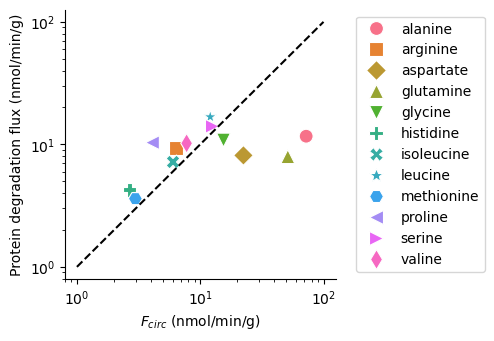

In [16]:
# Make a scatter plot comparing measured Ra vs estimated protein degradation flux for fasted mice (axes inverted)
f = plt.figure(figsize=(3.5, 3.5))

sns.scatterplot(
    data=comparison_df,
    x='Mean Ra C (nmol/min/g)',
    y='Protein Degradation Flux Fasted (nmol/min/g)',
    style='Tracer',
    hue='Tracer',
    markers=['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'H', '<', '>', 'd', 'p', 'h', '8'],
    s=100
)

plt.plot([1, 100], [1, 100], 'k--')
plt.xscale('log')
plt.yscale('log')

plt.xlabel('$F_{circ}$ (nmol/min/g)')
plt.ylabel('Protein degradation flux (nmol/min/g)')

# Add legend outside plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
